# Credit Card Fraud Detection Using Machine Learning

## Detecting Fraudulent Transactions through Predictive Analytics

**Author:** Che Francis

**Project Type:** Binary Classification

**Dataset:** European Credit Card Transactions (September 2013)

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

---

## Project Overview

Credit card fraud continues to be one of the biggest challenges facing financial institutions worldwide. As digital transactions increase, traditional rule-based fraud detection systems struggle to identify increasingly sophisticated fraudulent behavior.

In this project, we develop and compare several machine learning models capable of identifying fraudulent credit card transactions. Given the highly imbalanced nature of the dataset, special attention is paid to handling class imbalance, selecting appropriate evaluation metrics, and optimizing model performance.

The final objective is to recommend a machine learning model that provides the best balance between detecting fraudulent transactions while minimizing false alarms.

# Project Objectives

The objectives of this project are:

- Understand the characteristics of the fraud detection dataset.
- Perform exploratory data analysis to identify important patterns.
- Prepare the data for machine learning.
- Build multiple classification models.
- Handle severe class imbalance using various sampling techniques.
- Tune model hyperparameters.
- Compare model performance using appropriate evaluation metrics.
- Recommend the best-performing model from a business perspective.

# 1. Business Understanding

Credit card fraud is one of the fastest-growing financial crimes globally. Every fraudulent transaction results in financial losses, operational costs, customer dissatisfaction, and reputational damage for financial institutions.

Traditional fraud detection systems often rely on predefined rules. However, fraud patterns continually evolve, making rule-based systems less effective over time.

Machine learning offers the ability to learn complex transaction patterns from historical data and detect suspicious behavior automatically.

The primary objective of this project is therefore to build a predictive machine learning model capable of distinguishing fraudulent transactions from legitimate ones.

A major challenge of this dataset is that fraudulent transactions account for only a very small percentage of all observations. This creates a severe class imbalance that requires specialized preprocessing techniques and evaluation metrics.

Rather than maximizing overall accuracy, the focus of this project is to maximize the model's ability to correctly identify fraudulent transactions while minimizing false positives.

# 2. Data Understanding

Before building predictive models, it is important to understand the structure and quality of the dataset.

This section answers several important questions:

- How many observations are available?
- How many variables are included?
- Are there missing values?
- Are there duplicate observations?
- What are the data types?
- What does each feature represent?

Understanding the dataset helps identify potential quality issues before moving into exploratory analysis and model development.

In [ ]:
# Import Required Libraries

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display plots inline
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Load Dataset

df = pd.read_csv("../data/creditcard.csv")

# Display first five observations
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
# Dataset Dimensions

print(f"Number of Rows: {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 284,807
Number of Columns: 31


In [ ]:
# Dataset Information 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [13]:
# Missing Values

missing_values = df.isnull().sum()

missing_values


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [14]:
# Duplicate Records

duplicates = df.duplicated().sum()
print(f"Number of Duplicate Records: {duplicates:,}")

Number of Duplicate Records: 1,081


In [18]:
# Summary Statistics

df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## Business Insight

## Key Takeaways

From the initial inspection, we observe that:

- The dataset contains over 284,000 credit card transactions.
- All variables are numerical.
- No missing values are present.
- The target variable (`Class`) is binary.
- Most predictor variables have already been transformed using Principal Component Analysis (PCA).
- The `Amount` and `Time` variables remain in their original form and may require additional preprocessing.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential step in every machine learning project. It enables us to understand the underlying structure of the data, identify patterns, detect anomalies, and uncover relationships between variables before model development.

The objectives of this section are to:

- Understand the distribution of fraudulent and legitimate transactions.
- Explore the transaction amount and transaction time features.
- Investigate feature correlations.
- Detect skewness and potential outliers.
- Generate insights that will guide preprocessing and model selection.

The findings from this analysis will influence subsequent steps such as feature engineering, handling class imbalance, and model evaluation.

In [19]:
# Class Distribution 

class_counts = df["Class"].value_counts()

class_counts

Class
0    284315
1       492
Name: count, dtype: int64

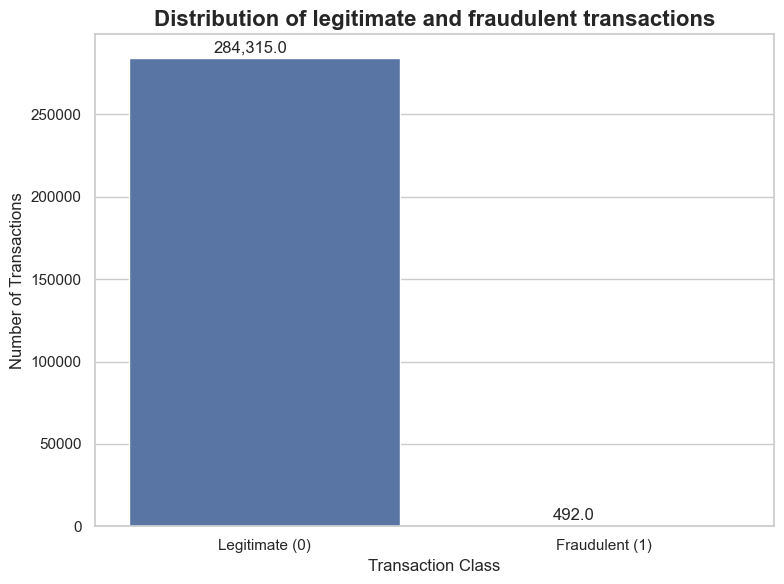

In [21]:
# Visualize Class Distribution

plt.figure(figsize=(8, 6))
colors = ["#4C72B0", "#DD8452"]
ax = sns.countplot(x="Class", data=df, palette=colors)

plt.title(
    "Distribution of legitimate and fraudulent transactions", fontsize=16, 
    fontweight="bold"
)
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

ax.set_xticklabels(["Legitimate (0)", "Fraudulent (1)"])

# Display values above each bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,}", 
        (p.get_x()+0.25, p.get_height()+3000), 
        fontsize=12,
    )
plt.tight_layout()
plt.show()

### Interpretation

The visualization clearly demonstrates that the dataset is highly imbalanced.

Out of more than **284,000 transactions**, only **492** are fraudulent, representing approximately **0.17%** of the total observations.

This is a common characteristic of fraud detection problems where fraudulent activities are naturally rare.

Such imbalance presents a challenge because a model can achieve very high accuracy simply by predicting every transaction as legitimate. Therefore, accuracy alone will not be an appropriate evaluation metric for this project.

Instead, metrics such as **Precision**, **Recall**, **F1-Score**, and **ROC-AUC** will provide a more reliable assessment of model performance.

In [22]:
# Percentage Distribution


percentage = (
    df["Class"]
    .value_counts(normalize=True)
    *100
).round(3)

percentage

Class
0    99.827
1     0.173
Name: proportion, dtype: float64

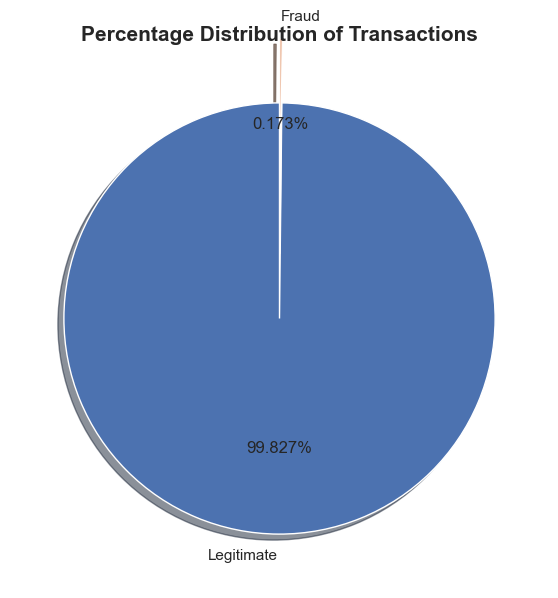

In [23]:
plt.figure(figsize=(7,7))

explode = (0,0.3)

plt.pie(
    percentage,
    labels=["Legitimate","Fraud"],
    autopct="%1.3f%%",
    colors=["#4C72B0","#DD8452"],
    explode=explode,
    startangle=90,
    shadow=True
)

plt.title(
    "Percentage Distribution of Transactions",
    fontsize=15,
    fontweight="bold"
)

plt.show()

### Business Insight

Although fraudulent transactions account for only a very small proportion of all transactions, they represent the transactions with the greatest financial impact.

This imbalance reinforces the importance of designing models that prioritize detecting fraudulent cases without generating an excessive number of false alarms.


In [24]:
# Summary Statistics for Amount

df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

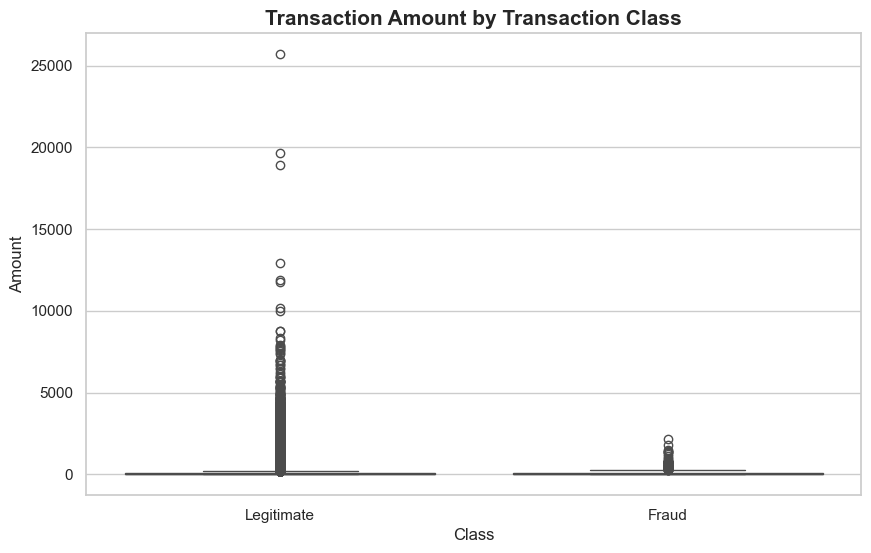

In [25]:
# Fraud vs Amount Visualization

plt.figure(figsize=(10,6))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df,
    palette=["#4C72B0","#DD8452"]
)

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.title(
    "Transaction Amount by Transaction Class",
    fontsize=15,
    fontweight="bold"
)

plt.show()

### Interpretation

Fraudulent transactions are not exclusively associated with large transaction amounts.

Fraud occurs across a wide range of transaction values.

This suggests that transaction amount alone is unlikely to provide sufficient discriminatory power for fraud detection and should be combined with other predictive features.